# Cargar datos experimentales 

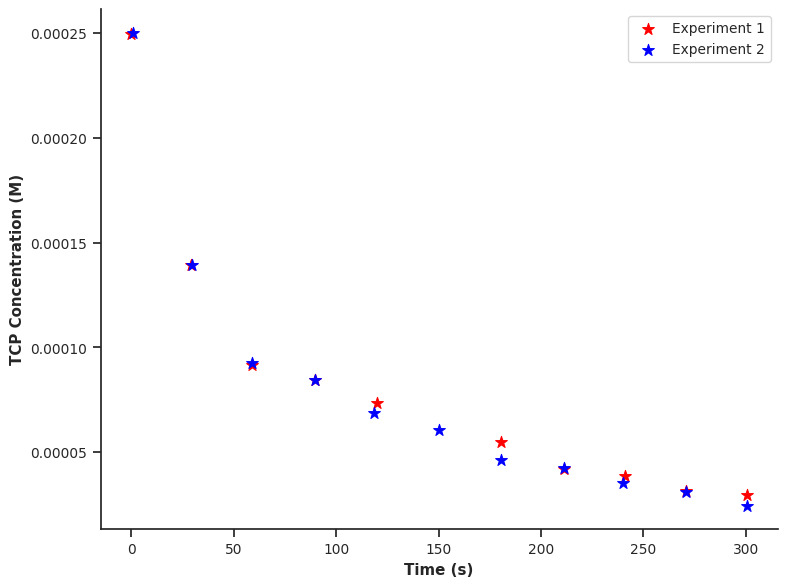

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# sugerencia profe: usar seaborn para los graficos

df_test1 = pd.read_csv("SBP_b_exp1.csv")
df_test2 = pd.read_csv("SBP_b_exp2.csv")
#print(df_test1.head())
df_test1 = df_test1.rename(columns={' y': 'y'})
df_test2 = df_test2.rename(columns={' y': 'y'})
df_test1['y'] = df_test1['y']*1e-4 # Convertir a M
df_test2['y'] = df_test2['y']*1e-4 # Convertir a M


# Graficar datos experimentales 
sns.set_theme(style="ticks", context="notebook", font_scale=0.9)

plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=df_test1['x'], 
    y=df_test1['y'], 
    color="red",      # Rojo elegante
    marker="*",           # "s" para cuadrado (square), imitando el paper original
    s=80,                 # Tamaño del marcador
    edgecolor="red",    # Borde negro alrededor del punto para mayor contraste
    zorder=3,             # Asegura que los puntos queden por encima de la línea
    label="Experiment 1"
)

sns.scatterplot(
    x=df_test2['x'], 
    y=df_test2['y'], 
    color="blue",      # Rojo elegante
    marker="*",           # "s" para cuadrado (square), imitando el paper original
    s=80,                 # Tamaño del marcador
    edgecolor="blue",    # Borde negro alrededor del punto para mayor contraste
    zorder=3,             # Asegura que los puntos queden por encima de la línea
    label="Experiment 2"
)
# ==========================================
# Ajustes finales del gráfico
# ==========================================
plt.xlabel("Time (s)", fontweight='bold')
plt.ylabel("TCP Concentration (M)", fontweight='bold')
#plt.title(f"Degradación de TCP - SBP {SBP_mg_mL} mg/mL", pad=15)

# Remover los bordes superior y derecho (muy común en papers)
sns.despine()

# Configurar la leyenda
plt.legend(frameon=True, loc="upper right", shadow=False)

# Ajustar el espaciado para que nada quede cortado
plt.tight_layout()

plt.show()

# Condiciones Iniciales

In [2]:
# Convertir todo a Molar (M)
TCP_0 = 0.25e-3  # 0.25 mM
H2O2_0 = 0.6e-3  # 0.6 mM
P_0 = 0.0
CpI_0 = 0.0
CpII_0 = 0.0
CpIII_0 = 0.0
CpI_H2O2_0 = 0.0
SBP_inact_0 = 0.0 # Inicialmente no hay enzima inactiva

# CONVERSIÓN DE SBP: mg/mL a Molaridad
# Ejemplo para 0.001 mg/mL. Ajusta el Peso Molecular (MW_SBP) según corresponda.
MW_SBP = 37000  # g/mol 
SBP_mg_mL = 0.001 # Cambia esto por 0.0005 o 0.002 según el set de datos que uses 
SBP_0 = (SBP_mg_mL) / MW_SBP # (g/L) / (g/mol) = mol/L = M

# 

# Caso b: SBP: 0.0001 mg/mL
y0_1 = [SBP_0, CpI_0, CpII_0, H2O2_0, TCP_0, P_0]
y0_1prima = [H2O2_0, TCP_0, P_0]
y0_2 = [SBP_0, CpI_0, CpII_0, H2O2_0, TCP_0, CpIII_0, P_0]
y0_3 = [SBP_0, CpI_0, CpII_0, H2O2_0, TCP_0, CpIII_0, CpI_H2O2_0, P_0]
y0_4 = [SBP_0, CpI_0, CpII_0, H2O2_0, TCP_0, P_0, SBP_inact_0]
y0_5 = [SBP_0, CpI_0, CpII_0, H2O2_0, TCP_0, CpIII_0, P_0, SBP_inact_0]
y0_6 = [SBP_0, CpI_0, CpII_0, H2O2_0, TCP_0, CpIII_0, CpI_H2O2_0, P_0, SBP_inact_0]


# Obtengo concentracion final de TCP en data experimental --> promedio dos últimos valores
TCP_f = (df_test1['y'].iloc[-1] + df_test2['y'].iloc[-1])/2

# Calculo Ks
Ks = ((TCP_0 - TCP_f)/SBP_0)
print(f"Ks = {Ks:.2e} M")

Ks = 8.25e+03 M


# Definicion de sistemas de ecuaciones 

## Modelo 1

In [3]:
from scipy.integrate import solve_ivp


def modelo_1(t, y, k1, k2, k3):
    # Desempaquetar las variables de estado (Concentraciones en Molar)
    SBP, CpI, CpII, H2O2, TCP, P = y
    
    # Sistema de EDOs según el Modelo 1 (Ecuaciones 12 a 17) 
    d_SBP = -k1 * SBP * H2O2 + k3 * CpII * TCP
    d_CpI = k1 * SBP * H2O2 - k2 * CpI * TCP
    d_CpII = k2 * CpI * TCP - k3 * CpII * TCP
    d_H2O2 = -k1 * SBP * H2O2
    d_TCP = -k2 * CpI * TCP - k3 * CpII * TCP
    d_P = k2 * CpI * TCP + k3 * CpII * TCP
    
    return [d_SBP, d_CpI, d_CpII, d_H2O2, d_TCP, d_P]

# ==========================================
# 2. Parámetros del Modelo 1 (Tabla 2) 
# ==========================================
k1_1 = 2.0e7
k2_1 = 6.4e6
k3_1 = 2.5e5

## Modelo 2

In [4]:
def modelo_2(t, y, k1, k2, k3, kapp, ka, kb, kc):
    # Variables de estado (7 variables)
    SBP, CpI, CpII, H2O2, TCP, CpIII, P = y
    
    # Sistema de EDOs
    d_SBP = -k1 * SBP * H2O2 + k3 * CpII * TCP + ka * CpIII + kc * CpI * H2O2
    d_CpI = k1 * SBP * H2O2 - k2 * CpI * TCP + kb * CpIII * TCP - kc * CpI * H2O2
    d_CpII = k2 * CpI * TCP - k3 * CpII * TCP - kapp * CpII * H2O2
    d_CpIII = kapp * CpII * H2O2 - ka * CpIII - kb * CpIII * TCP
    
    d_H2O2 = -k1 * SBP * H2O2 - kapp * CpII * H2O2 - kc * CpI * H2O2
    d_TCP = -k2 * CpI * TCP - k3 * CpII * TCP - kb * CpIII * TCP
    d_P = k2 * CpI * TCP + k3 * CpII * TCP + kb * CpIII * TCP
    
    return [d_SBP, d_CpI, d_CpII, d_H2O2, d_TCP, d_CpIII, d_P]

# ==========================================
# 2. Parámetros del Modelo 2 (Tabla 2) 
# ==========================================
k1_2 = 2.0e7 
k2_2 = 2.52e6 
k3_2 = 9.72e6 
kapp_2 = 7.92e-1 
ka_2 = 4.28e-2 
kb_2 = 4.23e-1 
kc_2 = 1.96e2

## Modelo 3

In [5]:
def modelo_3(t, y, k1, k2, k3, kapp, ka, kb, k4, k_minus4, k5):
    # Variables de estado (8 variables)
    SBP, CpI, CpII, H2O2, TCP, CpIII, CpI_H2O2, P = y
    
    # Sistema de EDOs
    d_SBP = -k1 * SBP * H2O2 + k3 * CpII * TCP + ka * CpIII + k5 * CpI_H2O2
    d_CpI = k1 * SBP * H2O2 - k2 * CpI * TCP + kb * CpIII * TCP - k4 * CpI * H2O2 + k_minus4 * CpI_H2O2
    d_CpII = k2 * CpI * TCP - k3 * CpII * TCP - kapp * CpII * H2O2
    d_CpIII = kapp * CpII * H2O2 - ka * CpIII - kb * CpIII * TCP
    d_CpI_H2O2 = k4 * CpI * H2O2 - k_minus4 * CpI_H2O2 - k5 * CpI_H2O2
    
    d_H2O2 = -k1 * SBP * H2O2 - kapp * CpII * H2O2 - k4 * CpI * H2O2 + k_minus4 * CpI_H2O2
    d_TCP = -k2 * CpI * TCP - k3 * CpII * TCP - kb * CpIII * TCP
    d_P = k2 * CpI * TCP + k3 * CpII * TCP + kb * CpIII * TCP
    
    return [d_SBP, d_CpI, d_CpII, d_H2O2, d_TCP, d_CpIII, d_CpI_H2O2, d_P]

# ==========================================
# 2. Parámetros del Modelo 3 (Tabla 2) 
# ==========================================
k1_3 = 2.0e7 
k2_3 = 3.36e6 
k3_3 = 8.85e5 
kapp_3 = 8.99e-2 
ka_3 = 6.48e-2 
kb_3 = 3.74e-1 
k4_3 = 3.41e1  
k_minus4_3 = 7.26e-7 
k5_3 = 1.41e0

## Modelo 1 con calculo de CpI y CpII

In [6]:
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ==========================================
# 1. Definición del Sistema de Ecuaciones (Modelo 1 prima)
# ==========================================
def modelo_1prima(t, y, k1, k2, k3, SBP_0):
    # Desempaquetar las variables de estado (Concentraciones en Molar)
    H2O2, TCP, P = y
    
    if TCP <=0:
        TCP = 1e-20
    
    # Sistema de EDOs según el Modelo 1 (Ecuaciones 12 a 17) [cite: 200, 203, 206, 211, 215, 219, 223]
    
    alpha = ( k1 * H2O2)/(k2*TCP) + (k1*H2O2)/(k3*TCP)
    SBP = SBP_0/(1+alpha) #ss
    
    CpI = ( k1 * H2O2 * SBP  ) / (k2 * TCP ) #ss
    
    CpII = ( k2 * CpI ) / k3 #ss
    
    d_H2O2 = -k1 * SBP * H2O2
    d_TCP = -k2 * CpI * TCP - k3 * CpII * TCP
    d_P = k2 * CpI * TCP + k3 * CpII * TCP
    
    return [d_H2O2, d_TCP, d_P]


## Modelo 4

In [7]:
# ==========================================
# 1. Definición del Sistema de Ecuaciones (Modelo 4)
# ==========================================

def modelo_4(t, y, k1, k2, k3, Ks):
    SBP, CpI, CpII, H2O2, TCP, P, SBP_inact = y
    
    # Velocidad de consumo de TCP (reacciones 2 y 3)
    rate_TCP_consumo = k2 * CpI * TCP + k3 * CpII * TCP
    

    # Tasa de inactivación de la enzima (derivada de la Eq. 11)
    d_SBP_inact = rate_TCP_consumo / Ks
    
    # Sistema de EDOs
    d_SBP = -k1 * SBP * H2O2 + k3 * CpII * TCP - d_SBP_inact
    d_CpI = k1 * SBP * H2O2 - k2 * CpI * TCP
    d_CpII = k2 * CpI * TCP - k3 * CpII * TCP
    d_H2O2 = -k1 * SBP * H2O2
    d_TCP = -rate_TCP_consumo
    d_P = rate_TCP_consumo
    
    return [d_SBP, d_CpI, d_CpII, d_H2O2, d_TCP, d_P, d_SBP_inact]
# ==========================================
# 2. Parámetros del Modelo 4 (Tabla 2) 
# ==========================================
k1_4 = 2.0e7
k2_4 = 3.4e6
k3_4 = 8.8e5

## Modelo 5

In [8]:
def modelo_5(t, y, k1, k2, k3, kapp, ka, kb, kc, Ks):
    # Variables de estado (8 variables)
    SBP, CpI, CpII, H2O2, TCP, CpIII, P, SBP_inact = y
    
    # Velocidad de consumo de TCP (reacciones 2, 3 y 6 del paper)
    rate_TCP_consumo = k2 * CpI * TCP + k3 * CpII * TCP + kb * CpIII * TCP
    
    # Tasa de inactivación
    d_SBP_inact = rate_TCP_consumo / Ks
    
    # Sistema de EDOs
    d_SBP = -k1 * SBP * H2O2 + k3 * CpII * TCP + ka * CpIII + kc * CpI * H2O2 - d_SBP_inact
    d_CpI = k1 * SBP * H2O2 - k2 * CpI * TCP + kb * CpIII * TCP - kc * CpI * H2O2
    d_CpII = k2 * CpI * TCP - k3 * CpII * TCP - kapp * CpII * H2O2
    d_CpIII = kapp * CpII * H2O2 - ka * CpIII - kb * CpIII * TCP
    
    d_H2O2 = -k1 * SBP * H2O2 - kapp * CpII * H2O2 - kc * CpI * H2O2
    d_TCP = -rate_TCP_consumo
    d_P = rate_TCP_consumo
    
    return [d_SBP, d_CpI, d_CpII, d_H2O2, d_TCP, d_CpIII, d_P, d_SBP_inact]


# ==========================================
# 2. Parámetros del Modelo 5 (Tabla 2) 
# ==========================================
k1_5 = 2.0e7 
k2_5 = 2.52e6 
k3_5 = 9.72e5 
kapp_5 = 7.92e-1 
ka_5 = 4.28e-2 
kb_5 = 4.23e-1 
kc_5 = 1.96e2

## Modelo 6

In [9]:
def modelo_6(t, y, k1, k2, k3, kapp, ka, kb, k4, k_minus4, k5, Ks):
    # Variables de estado (9 variables)
    SBP, CpI, CpII, H2O2, TCP, CpIII, CpI_H2O2, P, SBP_inact = y
    
    # Velocidad de consumo de TCP
    rate_TCP_consumo = k2 * CpI * TCP + k3 * CpII * TCP + kb * CpIII * TCP
    
    # Tasa de inactivación
    d_SBP_inact = rate_TCP_consumo / Ks
    
    # Sistema de EDOs
    d_SBP = -k1 * SBP * H2O2 + k3 * CpII * TCP + ka * CpIII + k5 * CpI_H2O2 - d_SBP_inact
    d_CpI = k1 * SBP * H2O2 - k2 * CpI * TCP + kb * CpIII * TCP - k4 * CpI * H2O2 + k_minus4 * CpI_H2O2
    d_CpII = k2 * CpI * TCP - k3 * CpII * TCP - kapp * CpII * H2O2
    d_CpIII = kapp * CpII * H2O2 - ka * CpIII - kb * CpIII * TCP
    d_CpI_H2O2 = k4 * CpI * H2O2 - k_minus4 * CpI_H2O2 - k5 * CpI_H2O2
    
    d_H2O2 = -k1 * SBP * H2O2 - kapp * CpII * H2O2 - k4 * CpI * H2O2 + k_minus4 * CpI_H2O2
    d_TCP = -rate_TCP_consumo
    d_P = rate_TCP_consumo
    
    return [d_SBP, d_CpI, d_CpII, d_H2O2, d_TCP, d_CpIII, d_CpI_H2O2, d_P, d_SBP_inact]

# ==========================================
# 2. Parámetros del Modelo 6 (Tabla 2) 
# ==========================================
k1_6 = 2.0e7 
k2_6 = 3.36e6 
k3_6 = 8.85e5 
kapp_6 = 8.99e-2 
ka_6 = 6.48e-2 
kb_6 = 3.74e-1 
k4_6 = 3.41e1  
k_minus4_6 = 7.26e-7 
k5_6 = 1.41e0

# Solver y Graficos

In [10]:
# ==========================================
# 4. Configuración del Solver
# ==========================================
# Suponiendo que tus datos experimentales llegan hasta 300 segundos
t_span = (0, 300)
# Vector de tiempo donde queremos que el solver entregue resultados para graficar suavemente
t_eval = np.linspace(t_span[0], t_span[1], 100)

# Resolviendo el sistema con método BDF (para sistemas rígidos) 
sol1 = solve_ivp(modelo_1, t_span, y0_1, method='BDF', t_eval=t_eval, args=(k1_1, k2_1, k3_1),rtol=1e-8, atol=1e-10)
#sol1prima = solve_ivp(modelo_1prima, t_span, y0_1prima, method='BDF', t_eval=t_eval, args=(k1, k2, k3,SBP_0),rtol=1e-8, atol=1e-10)
sol2 = solve_ivp(modelo_2, t_span, y0_2, method='BDF', t_eval=t_eval, args=(k1_2, k2_2, k3_2, kapp_2, ka_2, kb_2, kc_2),rtol=1e-8, atol=1e-10)
sol3 = solve_ivp(modelo_3, t_span, y0_3, method='BDF', t_eval=t_eval, args=(k1_3, k2_3, k3_3, kapp_3, ka_3, kb_3, k4_3, k_minus4_3, k5_3),rtol=1e-8, atol=1e-10)
sol4 = solve_ivp(modelo_4, t_span, y0_4, method='BDF', t_eval=t_eval, args=(k1_4, k2_4, k3_4, Ks),rtol=1e-8, atol=1e-10)
sol5 = solve_ivp(modelo_5, t_span, y0_5, method='BDF', t_eval=t_eval, args=(k1_5, k2_5, k3_5, kapp_5, ka_5, kb_5, kc_5, Ks),rtol=1e-8, atol=1e-10)
sol6 = solve_ivp(modelo_6, t_span, y0_6, method='BDF', t_eval=t_eval, args=(k1_6, k2_6, k3_6, kapp_6, ka_6, kb_6, k4_6, k_minus4_6, k5_6, Ks),rtol=1e-8, atol=1e-10)



## Concatenar soluciones para luego graficar 

In [11]:
# 1. Agrupamos las soluciones en un diccionario para iterar fácilmente
soluciones = {
    'Modelo 1': sol1,
    'Modelo 2': sol2,
    'Modelo 3': sol3,
    'Modelo 4': sol4,
    'Modelo 5': sol5,
    'Modelo 6': sol6
}

# 2. Creamos una lista vacía para guardar los DataFrames individuales
lista_dfs = []

# 3. Iteramos sobre cada solución para extraer los datos
for nombre_modelo, sol in soluciones.items():
    # Creamos un DataFrame temporal por cada modelo
    df_temp = pd.DataFrame({
        'Time': sol.t,
        'TCP_mM': sol.y[4],  # Multiplicamos por 1000 para pasar de M a mM
        'Modelo': nombre_modelo     # Esta será nuestra columna categórica para el 'hue'
    })
    
    # Lo agregamos a nuestra lista
    lista_dfs.append(df_temp)

# 4. Concatenamos todo en un único DataFrame "long-form"
df_simulaciones = pd.concat(lista_dfs, ignore_index=True)

df_simulaciones.head()

,Time,TCP_mM,Modelo
0,0.000000,0.000250,Modelo 1
1,3.030303,0.000240,Modelo 1
2,6.060606,0.000231,Modelo 1
3,9.090909,0.000222,Modelo 1
4,12.121212,0.000214,Modelo 1


## Graficar

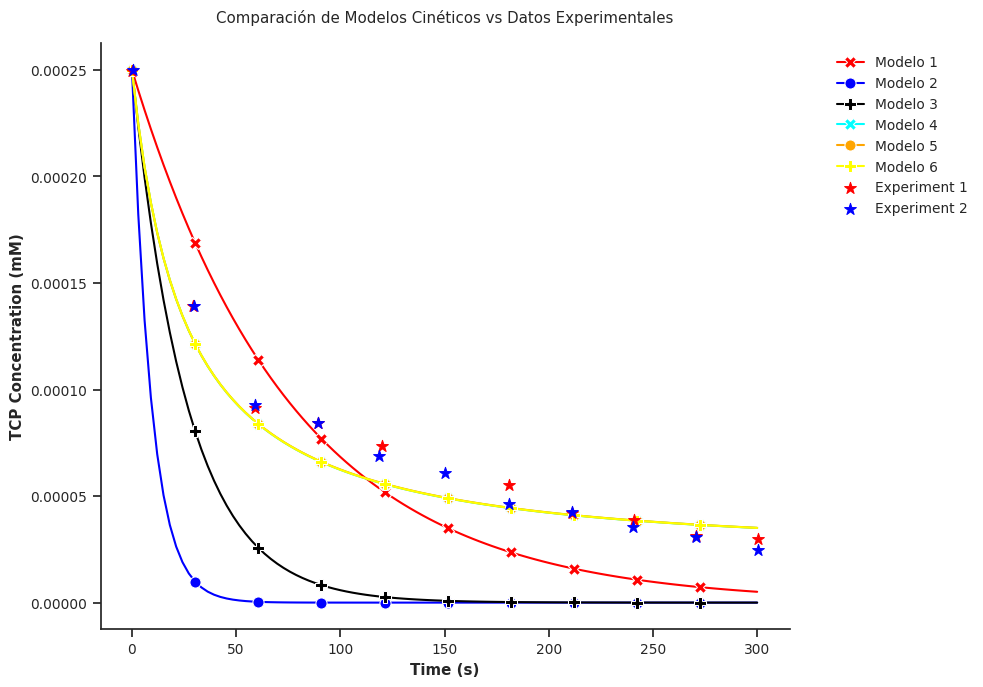

In [12]:
# ==========================================
# 5. Visualización vs Datos Experimentales
# ==========================================

# Configuramos el estilo tipo paper
sns.set_theme(style="ticks", context="notebook", font_scale=0.9)

plt.figure(figsize=(10, 7))

# 1. Definimos los colores exactos de cada modelo
colores_custom = {
    'Modelo 1': 'red',  
    'Modelo 2': 'blue',  
    'Modelo 3': 'black',  
    'Modelo 4': 'cyan', 
    'Modelo 5': 'orange',  
    'Modelo 6': 'yellow'  
}

# 2. Definimos los marcadores para cada modelo
marcadores_custom = {
    'Modelo 1': 'X',  # Equis
    'Modelo 2': 'o',  # Círculo
    'Modelo 3': 'P',  # Cruz (Plus)
    'Modelo 4': 'X',  # Estrella
    'Modelo 5': 'o',  # Cuadrado (square)
    'Modelo 6': 'P'   # Diamante  (diamond)
}

# Graficamos TODAS las simulaciones con una sola línea de código
# Seaborn se encarga de agrupar por 'Modelo' y asignar colores distintos gracias a 'hue'
sns.lineplot(
    data=df_simulaciones, 
    x='Time', 
    y='TCP_mM', 
    hue='Modelo',            # Asigna el color basado en el modelo
    palette=colores_custom,  # Aplica tu diccionario de colores
    style='Modelo',          # Asigna un estilo de marcador basado en el modelo
    markers=marcadores_custom, # Aplica tu diccionario de marcadores
    dashes=False,            # Falso para que TODAS las líneas sean continuas (no punteadas)
    linewidth=1.5,
    markevery=10,            # Pone un marcador cada 10 puntos de integración
    markersize=8             # Tamaño del símbolo en la línea
)

sns.scatterplot(
    x=df_test1['x'], 
    y=df_test1['y'], 
    color="red",      
    marker="*",           # estrella
    s=80,                 # Tamaño del marcador
    edgecolor="red",    # Borde negro alrededor del punto para mayor contraste
    zorder=3,             # Asegura que los puntos queden por encima de la línea
    label="Experiment 1"
)

sns.scatterplot(
    x=df_test2['x'], 
    y=df_test2['y'], 
    color="blue",     
    marker="*",           # estrella
    s=80,                 # Tamaño del marcador
    edgecolor="blue",    # Borde negro alrededor del punto para mayor contraste
    zorder=3,             # Asegura que los puntos queden por encima de la línea
    label="Experiment 2"
)

# Ajustes estéticos finales
plt.xlabel("Time (s)", fontweight='bold')
plt.ylabel("TCP Concentration (mM)", fontweight='bold')
plt.title("Comparación de Modelos Cinéticos vs Datos Experimentales", pad=15)

# Movemos la leyenda afuera del gráfico para que no tape las curvas
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
sns.despine()

plt.tight_layout()
plt.show()